# Permutation Tests

Check out the [alpaca tutorial](https://www.jwilber.me/permutationtest/) to view a visual explanation of permutation tests.

In [1]:
# Importing packages!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## What are Permutation Tests?

In the sciences, we often seek to explore if there are differences between distinct groups that are being studied. For example, we may want to see if there are differences in genetic sequences of different species of the same genus, or perhaps if there is a difference in height when growing plants in different growing conditions. 

When determining if groups are distinct, we evaluate the **null hypothesis**, which seeks to see if the data shows no difference between groups. In additional to the null hypothesis is the **alternative hypothesis**, which hypothesizes that there is a difference between groups.

A permutation test is a way to evaluate if there is indeed a difference between groups. The permutation test involves repeatedly simulating outcomes observed as if our null hypothesis is true. To do this, we randomly draw data across groups, then compare outcomes to determine if there are any differences.

## The Steps of a Permutation Test

Here are the basic steps of a permutation test. We'll go into more detail into each step later.
1. Identify a null hypothesis and an alternative hypothesis.

2. Choose a test statistic.

3. Permute the members of the original groups: Combine data, re-assign into fictive groups that match the size of the original samples, and recompute the test statistic.

4. Repeat this permutation many times, each time recording the test statistic.

5. Calculate the p-value to evaluate the null hypothesis.

## Performing a Permutation Test

We'll be using the alpaca dataset for performing a permutation test. The alpaca dataset contains data on a group of alpacas. The dataset is divided into two categories: treatment and control. The treatment column contains information on the alpacas undergoing a new shampoo treatment, while the control column contains information on the alpacas continuing with their normal shampoo. The data for each column is the wool quality of each alpaca.

Let's go through the steps of performing a permutation test with the alpaca dataset!

In [3]:
# Reads in the alpaca data
alpaca = pd.read_csv('alpaca.csv')
alpaca

,treatment,control
0,7.2,4.6
1,8.3,4.6
2,8.3,5.1
3,7.1,2.8
4,4.4,5.4
5,4.1,4.4
6,4.8,4.2
7,6.2,5.6
8,7.7,5.8
9,7.4,4.1


**Step 1:** Our null hypothesis for the alpaca data is that there **is no** difference between the two groups. Our alternative hypothesis is that there **is** a difference between the two groups.

**Step 2:** Let's choose the mean as our test statistic. We'll calculate the difference in means for each assigned group in each permutation.

Let's visualize the alpaca data by plotting the wool quality and the observed mean for each group.

Text(0.5, 1.0, 'Wood Quality across Treatment and Control Groups')

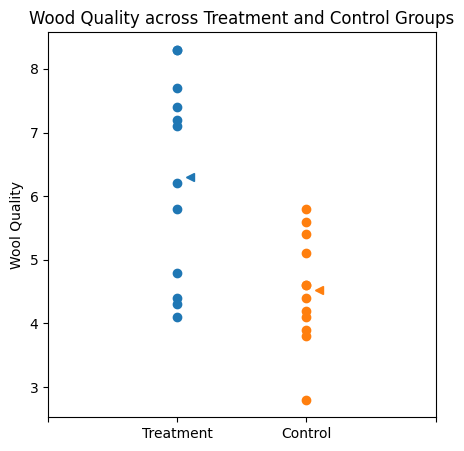

In [7]:
# Makes figure for plotting
fig, ax1 = plt.subplots(figsize = (5, 5))

# Creates x-values for the treatment and control groups
treat_xvals = np.zeros(len(alpaca['treatment']))
ctrl_xvals = np.zeros(len(alpaca['control'])) + 1

# Plots the treatment and control values
ax1.scatter(treat_xvals, alpaca['treatment'])
ax1.scatter(ctrl_xvals, alpaca['control'])

# Plots the mean of each treatment
ax1.plot(0.1, np.mean(alpaca['treatment']), '<')
ax1.plot(1.1, np.mean(alpaca['control']), '<')

# Edits axis ticks
ax1.set_xticks(np.array([-1, 0, 1, 2]))
ax1.set_xticklabels(['', 'Treatment', 'Control', ''])

# Adds plot labels
ax1.set_ylabel('Wool Quality')
ax1.set_title('Wood Quality across Treatment and Control Groups')

**Step 3:** We'll permute the data once. First, we combine all the data. Then, we shuffle, or permute, the data. Finally, we split the shuffled data into two fictional groups for the treatment and control groups.

In [28]:
# Combines the treatment and control data
combined_data = np.append(alpaca['treatment'], alpaca['control'])

# Shuffles the combined data
shuffled_data = np.random.permutation(combined_data)

# Splits into fictional treatment and control groups
fic_treat = shuffled_data[0:len(alpaca['treatment'])]
fic_control = shuffled_data[len(alpaca['treatment']):]

Let's visualize these random groupings to see how they compare to our original data.

Text(0.5, 1.0, 'Wood Quality across Permuted Treatment and Control Groups')

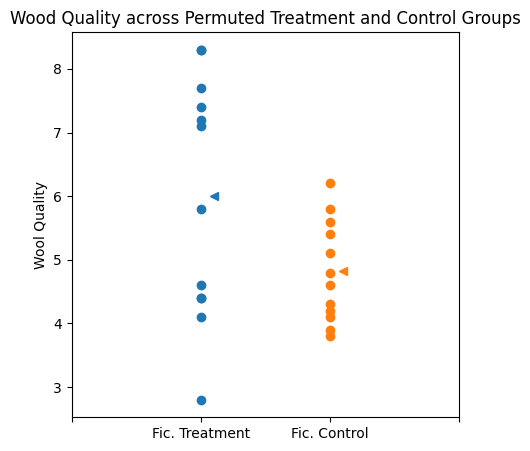

In [29]:
# Makes figure for plotting
fig, ax2 = plt.subplots(figsize = (5, 5))

# Plots the fictional permuted groups
ax2.scatter(treat_xvals, fic_treat)
ax2.scatter(ctrl_xvals, fic_control)

# Plots the means of the fictional groups
ax2.plot(0.1, np.mean(fic_treat), '<')
ax2.plot(1.1, np.mean(fic_control), '<')

# Edits axis ticks
ax2.set_xticks(np.array([-1, 0, 1, 2]))
ax2.set_xticklabels(['', 'Fic. Treatment', 'Fic. Control', ''])

# Adds plot labels
ax2.set_ylabel('Wool Quality')
ax2.set_title('Wood Quality across Permuted Treatment and Control Groups')

**Step 4:** To compare the groups effectively, we'll permute the data 1000 times. For each permutation, we'll record the differences in mean between the groups, as the mean is our chosen test statistic.

In [25]:
# Sets the number of permutations to 1000
num_permutations = 1000
# Creates a list to hold the mean differences for each permutation
mean_diff_list = []

# Performs the permutation 1000 times
for each_shuffle in range(num_permutations):

    # Shuffles the combined alpaca data
    shuffled_data = np.random.permutation(combined_data)

    # Splits into fictional treatment and control groups
    fic_treat = shuffled_data[0:len(alpaca['treatment'])]
    fic_control = shuffled_data[len(alpaca['treatment']):]

    # Calculates the mean difference between the groups
    mean_diff = np.mean(fic_treat) - np.mean(fic_control)

    # Adds the mean difference to the mean difference list
    mean_diff_list.append(mean_diff)

We can visualize the mean, our chosen test statistic, from our 1000 permutations.

Text(0.5, 1.0, 'Permuted Means Distribution for Alpaca Wool Quality')

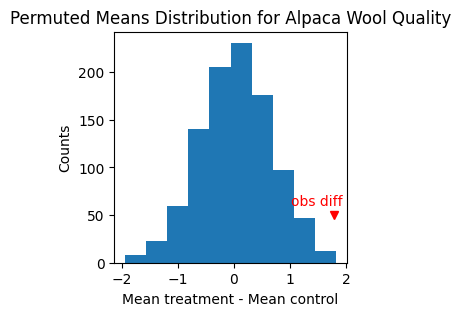

In [ ]:
# Creates figure for plotting
fig, ax3 = plt.subplots(figsize = (3,3))

# Makes a histogram of the means
ax3.hist(mean_diff_list)

# Overlays observed difference
obs_diff = np.mean(alpaca['treatment']) - np.mean(alpaca['control'])
ax3.plot(obs_diff, 50, 'rv')
ax3.text(obs_diff - 0.75, 60, 'obs diff', color = 'r')

# Sets the plot labels
ax3.set_ylabel('Counts')
ax3.set_xlabel('Mean treatment - Mean control')
ax3.set_title("Permuted Means Distribution for Alpaca Wool Quality")

**Step 5:** Finally, we'll calculate the **p-value** for the mean differences between the groups. The p-value is the probability that the null hypothesis is true, which means that there is no difference between group means. A low p-value means that there is likely a difference. 

We calculate the p-value by counting how many observed mean differences are equal or higher than the observed difference, which corresponds with the hypothesis that there is no difference. Then, we calculate the probability by dividing that value by the number of permutations.

In [27]:
# Calculates the null events
num_greater_than_observed = sum(np.array(mean_diff_list) >= obs_diff)

# Calculates the p-value
pvalue = num_greater_than_observed/num_permutations

# Views the p-value
print(f'The p-value is {pvalue}')

The p-value is 0.001


Our p-value is very low, meaning there is a low probability that the null hypothesis is true. Therefore, there is likely a difference in mean wool quality between the treatment and control groups.